## MNIST dataset example for topology search via gradient method 

### Load data 

In [1]:
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

In [2]:
# Load MNIST data
print("Loading MNIST data...")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Convert to numpy and flatten images
X = mnist_dataset.data.numpy().reshape(len(mnist_dataset), -1)  # (60000, 784)
y = mnist_dataset.targets.numpy()

# Split train/test (80/20)
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Loading MNIST data...
Splitting data...
Training set: (48000, 784), Test set: (12000, 784)


### Dimensionality analysis

Using n_neighbors: 783
Estimating dimensions using eigenvalue curvature method...
Estimating dimensions using variance threshold method...


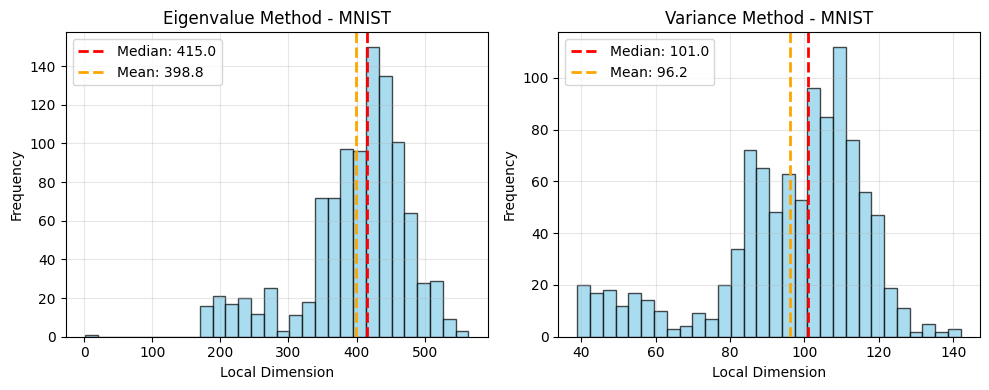


EIGENVALUE Method Summary:
  Median dimension: 415.0
  Mean dimension: 398.8
  Std dimension: 77.6
  Dimension range: 1 - 564
  Most common dimension: 458 (count: 13)

VARIANCE Method Summary:
  Median dimension: 101.0
  Mean dimension: 96.2
  Std dimension: 20.5
  Dimension range: 39 - 142
  Most common dimension: 108 (count: 40)
Calculating dimensions for different variance thresholds...
  Threshold 0.75...
  Threshold 0.80...
  Threshold 0.85...
  Threshold 0.90...
  Threshold 0.95...


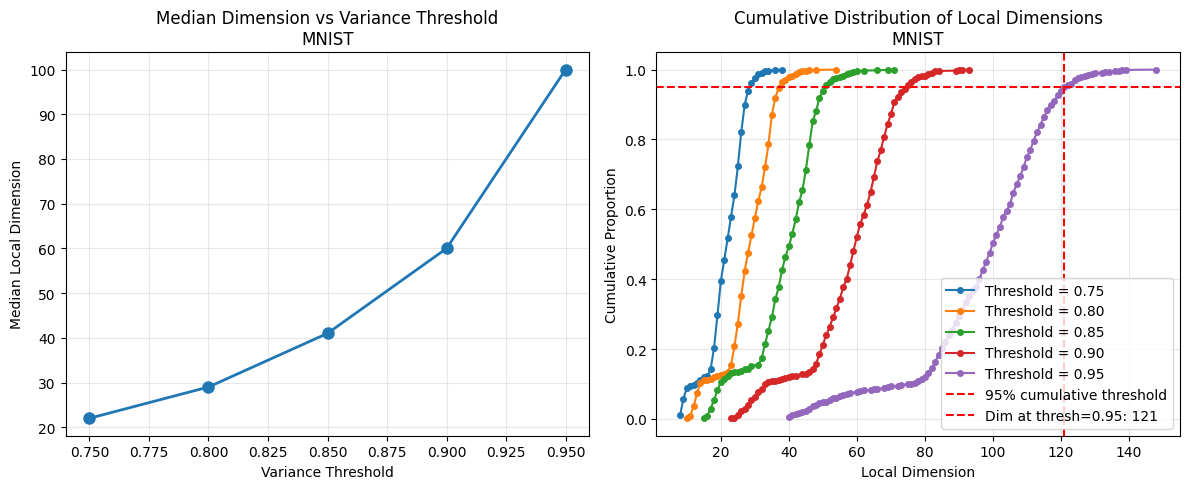

Recommended latent dimension (eigenvalue method): 398


In [3]:
from utils.DimensionalityAnalyser import DimensionalityAnalyser

analyser = DimensionalityAnalyser()

analyser.analyse_dimensions(
    X_train,
    method='both',
    n_samples=1000
)
analyser.plot_dimension_histograms(dataset_name="MNIST")
_, _ = analyser.plot_variance_threshold_analysis(X_train,
                                                 dataset_name="MNIST",
                                                 n_samples=1000)
latent_len = analyser.get_latent_dim(method='eigenvalue')

### FPS sparse points search and save

In [4]:
import numpy as np
import os
from utils.fps_implementation import memory_efficient_fps

In [5]:
working_folder = f'mnist_ex'
if not os.path.exists(working_folder):
    os.makedirs(working_folder)

In [6]:
if not os.path.exists(f'{working_folder}/fps_indices.npy'):
    print("Applying Farthest Point Sampling...")
    fps_indices = memory_efficient_fps(X_train, 2000)
    np.save(f'{working_folder}/fps_indices.npy', fps_indices)
    print(f"Sampled {len(fps_indices)} key points from training data")
else:
    fps_indices = np.load(f'{working_folder}/fps_indices.npy')

X_train_sparse = X_train[fps_indices]
y_train_sparse = y_train[fps_indices]

### Run manifold learning with GradientIsomap

In [ ]:
from Adam.GradientIsomap import GradientIsomap
import torch

print("Starting manifold learning...")

# Convert to torch tensors for GradientIsomap
train_features = torch.tensor(X_train_sparse, dtype=torch.float32).to('cuda')
train_target = torch.tensor(y_train_sparse, dtype=torch.float32).to('cuda')

isomap = GradientIsomap(
    train_feature=train_features,
    train_target=train_target,
    latent_len=latent_len,
    checkpoint_each=100,
    logs_folder=working_folder,
    plot_convergence=False,
    epochs=200
)

isomap.train()
isomap.visualize_trained()
matrix = isomap.best_distances_matrix
proj_features = isomap.best_isomap_model()

#### Or load existing topology

In [7]:
matrix = np.load(f'{working_folder}/best_distances_matrix.npy')
proj_features = np.load(f'{working_folder}/best_mapping.npy')

### Point-to-point projection for entire train and test

In [8]:
from utils.ProjectionMethods import ProjectionMethods

proj_train = ProjectionMethods.project_random_forest(X_sparse=X_train_sparse,
                                                     Y_sparse=proj_features,
                                                     X_all=X_train)
print(X_train_sparse.shape)
print(proj_train[0].shape)

  Using Random Forest projection...
  Random Forest projection completed in 1230.54s
(2000, 784)


AttributeError: 'tuple' object has no attribute 'shape'

### Inference for train and test

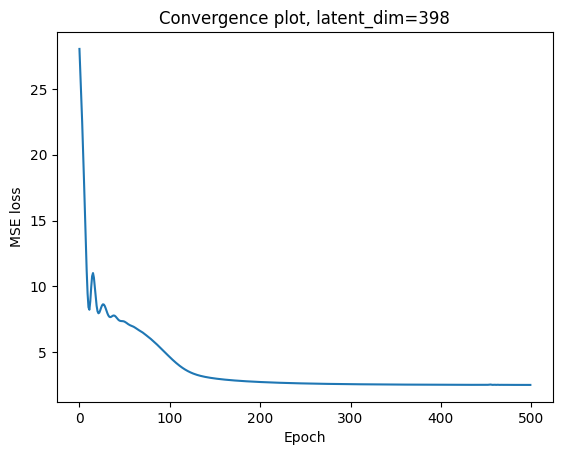

In [11]:
from structure_approximation.IntrinsicNN import IntrinsicNN
import torch

features = torch.tensor(proj_train[0], dtype=torch.float32).to('cuda')
y_train = torch.tensor(y_train, dtype=torch.float32).to('cuda')
task_model = IntrinsicNN(features,
                                  y_train,
                                  latent_len,
                                  plot_convergence=True,
                                  epochs=500)
task_model.train()

In [13]:
from torch.nn import L1Loss

output = task_model.model(features).flatten()
criterion = L1Loss()
print(f'Train MAE={criterion(output, y_train).item()}')

Train MAE=1.2204914093017578


In [14]:
proj_test = ProjectionMethods.project_random_forest(X_sparse=X_train_sparse,
                                                     Y_sparse=proj_features,
                                                     X_all=X_test)
print(X_test.shape)
print(proj_test[0].shape)

  Using Random Forest projection...
  Random Forest projection completed in 904.53s
(12000, 784)
(12000, 398)


In [16]:
test_features = torch.tensor(proj_test[0], dtype=torch.float32).to('cuda')
y_test = torch.tensor(y_test, dtype=torch.float32).to('cuda')
test_output = task_model.model(test_features).flatten()
print(f'Test MAE={criterion(test_output, y_test).item()}')

Train MAE=1.2048451900482178


C:\Users\Julia\AppData\Local\Temp\ipykernel_11212\1941786174.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype=torch.float32).to('cuda')
